In [4]:
## Step 1 — Load the Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Downloads/1st project.csv")
print(df.shape)       
print(df.head())
print(df.dtypes)


(45593, 20)
        ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
0  0x4607     INDORES13DEL02                   37                     4.9   
1  0xb379     BANGRES18DEL02                   34                     4.5   
2  0x5d6d     BANGRES19DEL01                   23                     4.4   
3  0x7a6a    COIMBRES13DEL02                   38                     4.7   
4  0x70a2     CHENRES12DEL01                   32                     4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_pi

In [3]:
## Step 2 — Inspect the Data
df.info()
df.describe()


print(df.isnull().sum())


print("Duplicates:", df.duplicated().sum())


cat_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order',
            'Type_of_vehicle', 'Festival', 'City']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [7]:
#Step 2 — Remove Trailing Spaces from String Columns
str_cols = df.select_dtypes(include="str").columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())


print(df["Road_traffic_density"].unique())


<StringArray>
['High', 'Jam', 'Low', 'Medium', 'unknown']
Length: 5, dtype: str


In [8]:
#Step 3 — Clean Weatherconditions (Remove "conditions " Prefix)

df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ", "", regex=False)


print(df["Weatherconditions"].unique())

<StringArray>
['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', 'unknown']
Length: 7, dtype: str


In [9]:
#Step 4 — Replace "unknown" with NaN

import numpy as np

df.replace("unknown", np.nan, inplace=True)
df.replace("NaN", np.nan, inplace=True) 


print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
time                              0
dtype: int64


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [16]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,time
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.584739,4.636552,17.017729,70.231332,17.465186,70.845702,1.023359,0.750225,26.294607
std,5.696333,0.327906,8.185109,22.883647,7.335122,21.118812,0.839065,0.567430,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,1.000000,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [17]:
# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y")


print(df["Order_Date"].dtype)    # datetime64[ns]

datetime64[us]


In [18]:
#Convert Time Columns to timedelta or datetime.time
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M:%S", errors="coerce").dt.time
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M:%S", errors="coerce").dt.time

In [21]:
#8 step to trename the column for consistency

df.rename(columns={
    "Time_Orderd":       "Time_Ordered",       
    "Delivery_person_Age":      "Delivery_Age"
    "Delivery_person_Ratings":  "Delivery_Rating",
    "multiple_deliveries":      "Multiple_Deliveries",
    "time":                     "Delivery_Time_mins"
}, inplace=True)

In [22]:
# Final shape and dtypes
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe(include="all"))

df.to_csv("1st_project_cleaned.csv", index=False)
print("Saved!")

(45593, 20)
ID                                        str
Delivery_person_ID                        str
Delivery_Age                          float64
Delivery_Rating                       float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                     datetime64[us]
Time_Ordered                           object
Time_Order_picked                      object
Weatherconditions                         str
Road_traffic_density                      str
Vehicle_condition                       int64
Type_of_order                             str
Type_of_vehicle                           str
Multiple_Deliveries                   float64
Festival                                  str
City                                      str
Delivery_Time_mins                      int64
dtype: object
ID                                0
Delivery_person_ID

In [32]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45593 non-null  str           
 1   Delivery_person_ID           45593 non-null  str           
 2   Delivery_Age                 45593 non-null  float64       
 3   Delivery_Rating              45593 non-null  float64       
 4   Restaurant_latitude          45593 non-null  float64       
 5   Restaurant_longitude         45593 non-null  float64       
 6   Delivery_location_latitude   45593 non-null  float64       
 7   Delivery_location_longitude  45593 non-null  float64       
 8   Order_Date                   45593 non-null  datetime64[us]
 9   Time_Ordered                 43862 non-null  object        
 10  Time_Order_picked            45593 non-null  object        
 11  Weatherconditions            45593 non-null  str    

In [34]:
df.head(30)

,ID,Delivery_person_ID,Delivery_Age,Delivery_Rating,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Ordered,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,Multiple_Deliveries,Festival,City,Delivery_Time_mins
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30
5,0x9bb4,HYDRES09DEL03,22.0,4.8,17.431668,78.408321,17.461668,78.438321,2022-03-11,21:20:00,21:30:00,Cloudy,Jam,0,Buffet,motorcycle,1.0,No,Urban,26
6,0x95b4,RANCHIRES15DEL01,33.0,4.7,23.369746,85.339820,23.479746,85.449820,2022-03-04,19:15:00,19:30:00,Fog,Jam,1,Meal,scooter,1.0,No,Metropolitian,40
7,0x9eb2,MYSRES15DEL02,35.0,4.6,12.352058,76.606650,12.482058,76.736650,2022-03-14,17:25:00,17:30:00,Cloudy,Medium,2,Meal,motorcycle,1.0,No,Metropolitian,32
8,0x1102,HYDRES05DEL02,22.0,4.8,17.433809,78.386744,17.563809,78.516744,2022-03-20,20:55:00,21:05:00,Stormy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,34
9,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55:00,22:10:00,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46


In [35]:
df = df.dropna(subset=['Time_Ordered'])
print(df.shape)  # should be 45593 - 1731 = 43862 rows

(43862, 20)


In [36]:
df.info()

<class 'pandas.DataFrame'>
Index: 43862 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           43862 non-null  str           
 1   Delivery_person_ID           43862 non-null  str           
 2   Delivery_Age                 43862 non-null  float64       
 3   Delivery_Rating              43862 non-null  float64       
 4   Restaurant_latitude          43862 non-null  float64       
 5   Restaurant_longitude         43862 non-null  float64       
 6   Delivery_location_latitude   43862 non-null  float64       
 7   Delivery_location_longitude  43862 non-null  float64       
 8   Order_Date                   43862 non-null  datetime64[us]
 9   Time_Ordered                 43862 non-null  object        
 10  Time_Order_picked            43862 non-null  object        
 11  Weatherconditions            43862 non-null  str         

,Delivery_Age,Delivery_Rating,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Vehicle_condition,Multiple_Deliveries,Delivery_Time_mins
count,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862,43862.000000,43862.000000,43862.000000
mean,29.557179,4.635682,17.241971,70.764932,17.462466,70.828527,2022-03-13 16:38:43.724408,1.000889,0.749624,26.293831
min,20.000000,2.500000,-30.902872,0.000000,0.010000,0.010000,2022-02-11 00:00:00,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.986229,73.279312,2022-03-04 00:00:00,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.554382,75.898497,18.633934,75.999490,2022-03-15 00:00:00,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,2022-03-27 00:00:00,2.000000,1.000000,32.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,2.000000,3.000000,54.000000
std,5.747493,0.312907,7.698686,21.136195,7.338540,21.136365,NaN,0.816557,0.567594,9.373765


In [41]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_Age                   0
Delivery_Rating                0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Ordered                   0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
Multiple_Deliveries            0
Festival                       0
City                           0
Delivery_Time_mins             0
dtype: int64

In [6]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'time'],
      dtype='str')

<Axes: xlabel='time', ylabel='Count'>

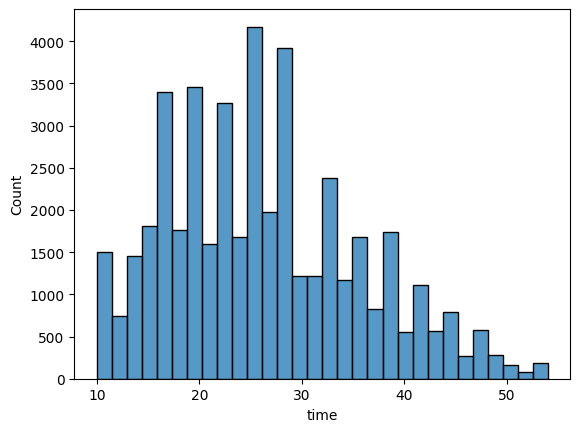

In [7]:
# lets do some eda process and check some outliers

# 1. Delivery time distribution
sns.histplot(df['time'], bins=30)



In [46]:
 df.to_csv("PROJECT.csv", index=False)


<Axes: xlabel='Road_traffic_density', ylabel='time'>

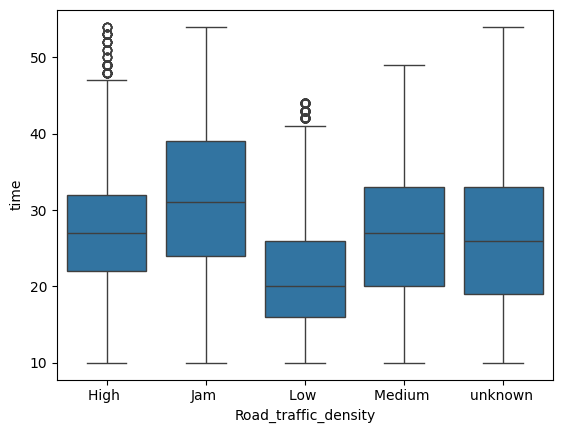

In [9]:
sns.boxplot(x='Road_traffic_density', y='time', data=df)

<Axes: xlabel='Weatherconditions', ylabel='time'>

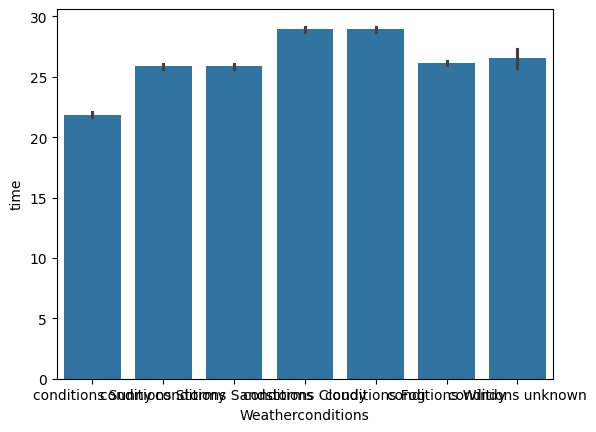

In [10]:
sns.barplot(x='Weatherconditions', y='time', data=df)


<Axes: xlabel='City'>

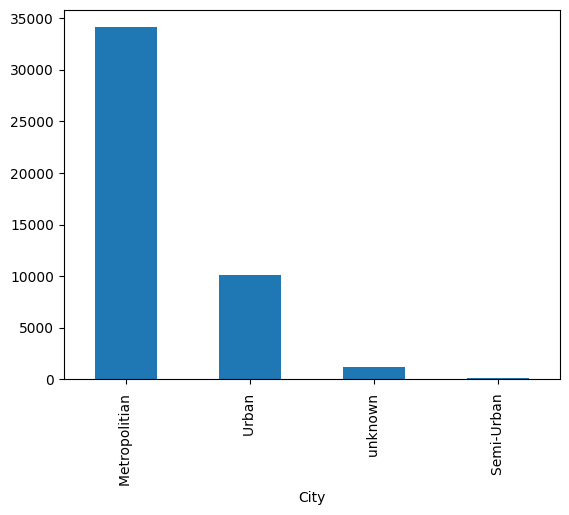

In [11]:
df['City'].value_counts().plot(kind='bar')

<Axes: >

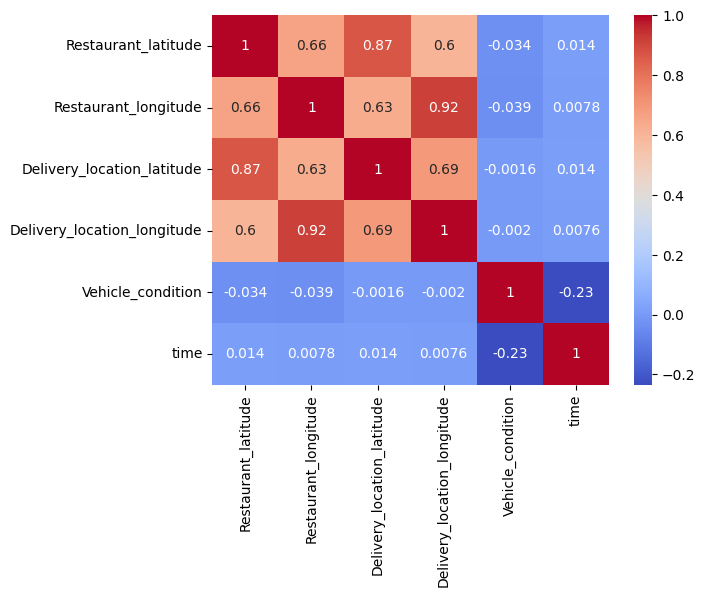

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')